In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('MicrosoftStock.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   1259 non-null   int64  
 1   date    1259 non-null   object 
 2   open    1259 non-null   float64
 3   high    1259 non-null   float64
 4   low     1259 non-null   float64
 5   close   1259 non-null   float64
 6   volume  1259 non-null   int64  
 7   Name    1259 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 78.8+ KB


In [4]:
df.head()

,index,date,open,high,low,close,volume,Name
0,390198,2013-02-08,27.35,27.71,27.31,27.55,33318306,MSFT
1,390199,2013-02-11,27.65,27.92,27.50,27.86,32247549,MSFT
2,390200,2013-02-12,27.88,28.00,27.75,27.88,35990829,MSFT
3,390201,2013-02-13,27.93,28.11,27.88,28.03,41715530,MSFT
4,390202,2013-02-14,27.92,28.06,27.87,28.04,32663174,MSFT


In [5]:
df['date']=pd.to_datetime(df['date'])

In [6]:
df.set_index('date',inplace=True)

In [7]:
df.head()

,index,open,high,low,close,volume,Name
date,,,,,,,
2013-02-08,390198,27.35,27.71,27.31,27.55,33318306,MSFT
2013-02-11,390199,27.65,27.92,27.50,27.86,32247549,MSFT
2013-02-12,390200,27.88,28.00,27.75,27.88,35990829,MSFT
2013-02-13,390201,27.93,28.11,27.88,28.03,41715530,MSFT
2013-02-14,390202,27.92,28.06,27.87,28.04,32663174,MSFT


In [8]:
df_copy=df[['open','high','low','close']]

In [9]:
df_copy.head()

,open,high,low,close
date,,,,
2013-02-08,27.35,27.71,27.31,27.55
2013-02-11,27.65,27.92,27.50,27.86
2013-02-12,27.88,28.00,27.75,27.88
2013-02-13,27.93,28.11,27.88,28.03
2013-02-14,27.92,28.06,27.87,28.04


In [10]:
df_copy.isnull().sum()

open     0
high     0
low      0
close    0
dtype: int64

In [11]:
df_copy.dtypes

open     float64
high     float64
low      float64
close    float64
dtype: object

In [12]:
from statsmodels.tsa.stattools import adfuller,kpss

In [13]:
def adf_test(series):
    adf_test=adfuller(series)
    print(f"adf stats:{round(adf_test[0],3)}")
    print(f"p-value stats:{round(adf_test[1],3)}")
    print(f"lags values:{round(adf_test[2],3)}")
    for key,value in adf_test[4].items():
     print(f"{key}:{round(value,3)}")
        
def kpss_test(series):
    kpss_test=kpss(series,regression='ct')
    print("KPSS Statistic:", kpss_test[0])
    print("p-value:", kpss_test[1])
    print("Lags used:", kpss_test[2])
    print("Critical values:", kpss_test[3].items())

In [14]:
for col in df_copy.columns:
    print(f"\n===== {col} =====")
    adf_test(df_copy[col])
    kpss_test(df_copy[col])


===== open =====
adf stats:0.6
p-value stats:0.988
lags values:1
1%:-3.436
5%:-2.864
10%:-2.568
KPSS Statistic: 0.874516532582117
p-value: 0.01
Lags used: 20
Critical values: dict_items([('10%', 0.119), ('5%', 0.146), ('2.5%', 0.176), ('1%', 0.216)])

===== high =====
adf stats:0.732
p-value stats:0.99
lags values:1
1%:-3.436
5%:-2.864
10%:-2.568
KPSS Statistic: 0.8638242479406639
p-value: 0.01
Lags used: 20
Critical values: dict_items([('10%', 0.119), ('5%', 0.146), ('2.5%', 0.176), ('1%', 0.216)])

===== low =====
adf stats:1.103
p-value stats:0.995
lags values:8
1%:-3.436
5%:-2.864
10%:-2.568
KPSS Statistic: 0.8852869114732366
p-value: 0.01
Lags used: 20
Critical values: dict_items([('10%', 0.119), ('5%', 0.146), ('2.5%', 0.176), ('1%', 0.216)])

===== close =====


C:\Users\Mcc\AppData\Local\Temp\ipykernel_17840\448176768.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test=kpss(series,regression='ct')
C:\Users\Mcc\AppData\Local\Temp\ipykernel_17840\448176768.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test=kpss(series,regression='ct')
C:\Users\Mcc\AppData\Local\Temp\ipykernel_17840\448176768.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test=kpss(series,regression='ct')


adf stats:0.416
p-value stats:0.982
lags values:0
1%:-3.436
5%:-2.864
10%:-2.568
KPSS Statistic: 0.876712863030781
p-value: 0.01
Lags used: 20
Critical values: dict_items([('10%', 0.119), ('5%', 0.146), ('2.5%', 0.176), ('1%', 0.216)])


C:\Users\Mcc\AppData\Local\Temp\ipykernel_17840\448176768.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test=kpss(series,regression='ct')


In [15]:
#above indicates that data has non stationarity

In [16]:
df_diff=df_copy.diff().dropna()

In [17]:
for col in df_diff.columns:
    result = adfuller(df_diff[col])

    print(f"{col}:")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")

    if result[1] < 0.05:
        print("Stationary\n")
    else:
        print("Not stationary\n")

open:
ADF Statistic: -37.0220
p-value: 0.0000
Stationary

high:
ADF Statistic: -33.7933
p-value: 0.0000
Stationary

low:
ADF Statistic: -14.5117
p-value: 0.0000
Stationary

close:
ADF Statistic: -36.4803
p-value: 0.0000
Stationary



In [18]:
df_diff.shape

(1258, 4)

In [19]:
#Important for stock prices: raw open/high/low/close prices are usually non-stationary. For financial time series,
#log returns are often more appropriate than simple price differences:

In [20]:
# df_copy = np.log(df[['open', 'high', 'low', 'close']]).diff().dropna()

<Axes: xlabel='date'>

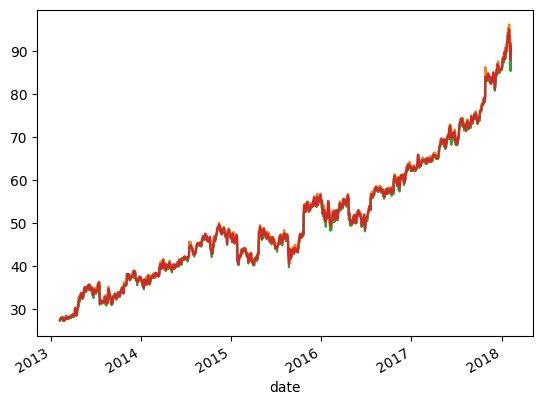

In [21]:
df_copy['open'].plot()
df_copy['high'].plot()
df_copy['low'].plot()
df_copy['close'].plot()

In [22]:
from statsmodels.tsa.api import VAR

In [23]:
train = df_diff.iloc[:-20]
test = df_diff.iloc[-20:]

In [24]:
train.shape,test.shape

((1238, 4), (20, 4))

In [25]:
model = VAR(train)

lag_order = model.select_order(maxlags=20)

print(lag_order.summary())

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -6.671      -6.654    0.001267      -6.665
1       -7.756      -7.672   0.0004282      -7.724
2       -8.128      -7.977   0.0002953      -8.071
3       -8.335      -8.117   0.0002399      -8.253
4       -8.427      -8.142   0.0002189      -8.320
5       -8.503     -8.151*   0.0002029      -8.370
6       -8.551      -8.132   0.0001934     -8.393*
7       -8.560      -8.074   0.0001916      -8.377
8       -8.579      -8.026   0.0001880      -8.371
9       -8.598      -7.978   0.0001845      -8.365
10      -8.604      -7.916   0.0001835      -8.345
11      -8.611      -7.857   0.0001821      -8.327
12      -8.615      -7.794   0.0001813      -8.306
13      -8.604      -7.715   0.0001835      -8.269
14      -8.602      -7.646   0.0001838      -8.242
15      -8.626      -7.603   0.0001795      -8.241
16      -8.628      -7.538   0.

In [26]:
# Method	 Purpose
# ACF	     Understand autocorrelation of an individual series
# PACF	     Help understand autoregressive lag structure
# AIC	    Select VAR lag
# BIC	    Select VAR lag, usually more conservative
# HQIC	    Another lag-selection criterion

In [27]:
print("AIC :", lag_order.aic)
print("BIC :", lag_order.bic)
print("HQIC:", lag_order.hqic)
print("FPE :", lag_order.fpe)

AIC : 18
BIC : 5
HQIC: 6
FPE : 18


In [28]:
selected_lag = lag_order.aic

In [29]:
selected_lag

np.int64(18)

In [30]:
results = model.fit(selected_lag)
print(results)

In [31]:
print("Selected lag:", results.k_ar)

Selected lag: 18


In [33]:
#k_ar means the number of autoregressive lags used in the model in VAR model.
#In statsmodels, k_ar is essentially the model's autoregressive order (p) in a VAR(p) model.

In [34]:
forecast = results.forecast(
    train.values[-results.k_ar:],
    steps=len(test)
)
#last k_ar rows of your training data
# steps=len(test)
#This tells the model how many future periods to predict.

In [36]:

forecast_df = pd.DataFrame(
    forecast,
    index=test.index,
    columns=test.columns
)
test_pred=df_copy.iloc[-1]+forecast_df.cumsum()

In [39]:
test = df_copy.iloc[-20:]

In [40]:
test.shape

(20, 4)

In [43]:
test

,open,high,low,close
date,,,,
2018-01-10,87.860,88.190,87.4100,87.82
2018-01-11,88.130,88.130,87.2400,88.08
2018-01-12,88.670,89.780,88.4500,89.60
2018-01-16,90.100,90.790,88.0104,88.35
2018-01-17,89.080,90.280,88.7500,90.14
2018-01-18,89.800,90.670,89.6600,90.10
2018-01-19,90.140,90.610,89.6600,90.00
2018-01-22,90.000,91.620,89.7400,91.61
2018-01-23,91.900,92.300,91.5400,91.90


In [41]:
print(test_pred) #here data is shown such kind of messy due to df.diff()

                 open       high        low      close
date                                                  
2018-01-10  90.003190  91.559771  88.912439  89.182032
2018-01-11  89.751859  91.485197  88.683830  89.176136
2018-01-12  89.654258  91.266805  88.408557  88.898788
2018-01-16  89.481033  91.260195  88.479412  89.130761
2018-01-17  89.909178  91.436862  88.732523  89.260382
2018-01-18  89.746938  91.353064  88.707856  89.282721
2018-01-19  89.879500  91.532897  88.935270  89.549174
2018-01-22  90.217270  91.761505  89.167714  89.644719
2018-01-23  90.251904  91.877078  89.314440  89.902460
2018-01-24  90.484070  91.968046  89.400776  89.917966
2018-01-25  90.532293  92.138621  89.520706  90.082134
2018-01-26  90.621643  92.225055  89.663489  90.115255
2018-01-29  90.657176  92.089509  89.601998  89.963814
2018-01-30  90.478114  92.057814  89.457770  89.938894
2018-01-31  90.474226  92.100806  89.422627  89.883574
2018-02-01  90.537011  92.106936  89.450107  89.931179
2018-02-02

In [42]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
for col in test.columns:
    mae = mean_absolute_error(
        test[col],
        test_pred[col]
    )
    print(col, "MAE:", mae)

open MAE: 1.8482835259766042
high MAE: 1.6475082707199882
low MAE: 1.9500230928190638
close MAE: 1.9942735803903695


In [44]:
for col in test.columns:
    mse = mean_squared_error(
        test[col],
        test_pred[col]
    )
    print(col, "MAE:", np.sqrt(mse))

open MAE: 2.321934653688166
high MAE: 2.009248410356993
low MAE: 2.396362597569088
close MAE: 2.403921140618767


In [45]:
# If you want actual price forecasts
# This is where cumsum() becomes important.

In [42]:
df1=df[['open','high','low','close']].iloc[:-20]

In [44]:
last_price = df1.iloc[-1]

In [45]:
last_price

open     88.6500
high     88.7272
low      87.8600
close    88.2200
Name: 2018-01-09 00:00:00, dtype: float64

In [46]:
forecast_prices = forecast_df.cumsum().add(last_price)

In [47]:
forecast_prices

,open,high,low,close
date,,,,
2018-01-10,88.163190,88.516971,87.572439,87.792032
2018-01-11,87.911859,88.442397,87.343830,87.786136
2018-01-12,87.814258,88.224005,87.068557,87.508788
2018-01-16,87.641033,88.217395,87.139412,87.740761
2018-01-17,88.069178,88.394062,87.392523,87.870382
2018-01-18,87.906938,88.310264,87.367856,87.892721
2018-01-19,88.039500,88.490097,87.595270,88.159174
2018-01-22,88.377270,88.718705,87.827714,88.254719
2018-01-23,88.411904,88.834278,87.974440,88.512460


In [51]:
df2=df[['open','high','low','close']].iloc[-20:]

print("Actual:")
print(df2)

Actual:
              open    high      low  close
date                                      
2018-01-10  87.860  88.190  87.4100  87.82
2018-01-11  88.130  88.130  87.2400  88.08
2018-01-12  88.670  89.780  88.4500  89.60
2018-01-16  90.100  90.790  88.0104  88.35
2018-01-17  89.080  90.280  88.7500  90.14
2018-01-18  89.800  90.670  89.6600  90.10
2018-01-19  90.140  90.610  89.6600  90.00
2018-01-22  90.000  91.620  89.7400  91.61
2018-01-23  91.900  92.300  91.5400  91.90
2018-01-24  92.550  93.430  91.5800  91.82
2018-01-25  92.465  93.240  91.9300  92.33
2018-01-26  93.120  94.060  92.5800  94.06
2018-01-29  95.140  95.450  93.7200  93.92
2018-01-30  93.300  93.660  92.1000  92.74
2018-01-31  93.750  95.400  93.5100  95.01
2018-02-01  94.790  96.070  93.5813  94.26
2018-02-02  93.640  93.970  91.5000  91.78
2018-02-05  90.560  93.240  88.0000  88.00
2018-02-06  86.890  91.475  85.2500  91.33
2018-02-07  90.490  91.770  89.2000  89.61
